In [50]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
def setup_mpl():
    mpl.rc('font', size = 9)
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['xtick.labelsize'] = 'small'
    mpl.rcParams['ytick.labelsize'] = 'small'
    mpl.rcParams['lines.linewidth'] = 1
    mpl.rcParams['xtick.major.width'] = 1
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.width'] = 1
    mpl.rcParams['xtick.major.size'] = 3
    mpl.rcParams['ytick.major.size'] = 3
    mpl.rcParams['xtick.minor.size'] = 1.5
    mpl.rcParams['ytick.minor.size'] = 1.5
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['xtick.top'] = False
    mpl.rcParams['ytick.right'] = False
    mpl.rcParams['mathtext.default'] = 'regular'
    mpl.rcParams['xtick.major.pad'] = '2.3'
    mpl.rcParams['ytick.major.pad' ]= '2.3'
    mpl.rcParams['axes.labelpad'] = 2

setup_mpl()


In [51]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import h3
import libpysal
from tqdm import tqdm
from shapely.geometry import Polygon, Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MinMaxScaler
import folium
import seaborn as sns
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import json
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

In [52]:

def h3_to_polygon(h3_hex):
    # Hex string to polygon
    coords = h3.h3_to_geo_boundary(h3_hex)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)

def get_data(countryID=None,case = "pre-covid"):
    countryname = dict_country[countryID]
    kind = "empirical"
    df = pd.read_csv("/work/netmob24/data/tmp/" + kind + "_" + case + "_" + countryname + ".csv")
    df["geometry"] = df["cell"].apply(h3_to_polygon)
    gdf_tmp = gpd.GeoDataFrame(df, geometry="geometry", crs = "EPSG:4326")
    case_mobility = "driving"
    df_driving = pd.read_csv("/work/netmob24/data/tmp/"+ case_mobility + "_"+countryname+".csv")
    gdf = pd.merge(gdf_tmp, df_driving, on = "cell",how ="inner")
    # Reorganize the data
    gdf = gdf.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
    gdf.rename(columns=dict_titles, inplace=True)
    gdf = pd.melt(gdf, id_vars=[case, case + '_cell', 'cell', 'geometry'],
                value_vars=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', "2 h"],
                var_name='threshold', value_name=case+'_th')
    return gdf


def bootstrap_median(data, n_bootstrap=1000):
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    medians = np.median(bootstrap_samples, axis=1)
    median_estimate = np.mean(data)
    se_median = np.std(medians)
    return median_estimate, se_median

def weighted_median(values, weights):
    """Compute weighted median"""
    sorted_idx = np.argsort(values)
    sorted_vals = np.array(values)[sorted_idx]
    sorted_weights = np.array(weights)[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    cutoff = 0.5 * sum(sorted_weights)
    return sorted_vals[cum_weights >= cutoff][0]

In [53]:
dict_country = {
    "co":"colombia",
    "mx":"mexico",
    "in":"india",
    "id":"indonesia"
}

dict_titles = {
        "5000":"10 min",
        "7500":"15 min",
        "10000":"20 min",
        "15000":"30 min",
        "22500":"45 min",
        "30000":"1 h",
        "60000":"2 h"
}

In [54]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()
gdf_info = gpd.read_file('/work/netmob24/data/cities/cities_info.geojson')
gdf = pd.merge(gdf, gdf_info.drop(columns=['geometry']), on = "name_city", how = "left")
cities = gdf["correct_name"].unique()
name_to_country = dict(zip(gdf['correct_name'], gdf['country']))

In [55]:
gdf = gdf[['cell', 'correct_name', 'country', 'pop_density', 'population', 'geometry']] # pop_density, population are at the city level

def lonlat_to_utm_epsg(lon, lat):
    """Infer UTM EPSG based on centroid lon/lat"""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        return 32600 + zone  # Northern Hemisphere
    else:
        return 32700 + zone  # Southern Hemisphere

def compute_city_compactness_auto_utm(gdf, city_col='city'):
    results = []

    # Ensure input is in WGS84
    gdf = gdf.to_crs("EPSG:4326")

    for city, city_gdf in gdf.groupby(city_col):
        # Compute centroid of all geometries
        centroid = city_gdf.geometry.unary_union.centroid
        lon, lat = centroid.x, centroid.y

        # Determine UTM EPSG
        epsg = lonlat_to_utm_epsg(lon, lat)

        # Project to local UTM CRS
        city_proj = city_gdf.to_crs(epsg=epsg)

        # Union of hexagons for this city
        geom_union = city_proj.geometry.unary_union

        # Compute area and perimeter
        area = geom_union.area
        perimeter = geom_union.length

        # Compactness
        compactness = (4 * np.pi * area) / (perimeter ** 2)

        results.append({
            city_col: city,
            'epsg': epsg,
            'area_m2': area,
            'perimeter_m': perimeter,
            'compactness': compactness
        })

    return gpd.GeoDataFrame(results)

def assign_compactness_cluster_within_country(group):
    median_c = group['compactness'].median()
    def cluster(row):
        if row['compactness'] <= median_c:
            return 1
        elif row['compactness'] > median_c:
            return 2

    group['Cluster'] = group.apply(cluster, axis=1)
    return group

def get_weekly_data(countryID=None):
    df1 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2019.csv")
    df2 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2020.csv")
    # Keep only pre-covid data
    df = pd.concat([df1, df2[df2["week_number"] < 10]], ignore_index=True)
    #only covid
    #df = df2[df2["week_number"] > 10].copy()
    # Focus on cities
    df = df[df["start_h3_7"].isin(cells2keep)]

    # Consider trips outside the focal cell
    # df = df[df["end_h3_7"] != df["start_h3_7"]]
    # Group and compute weighted medians
    result = df.groupby('start_h3_7').apply(
        lambda g: pd.Series({
            'wm_duration_min': weighted_median(g['m_duration_min'], g['trip_count']),
            'wm_length_m': weighted_median(g['mdn_length_m'], g['trip_count']) / 1000,  # Convert to km
        }), include_groups=False
    ).reset_index()
    return result.rename(columns={"start_h3_7": "cell"})

df_metrics = compute_city_compactness_auto_utm(gdf, city_col='correct_name')
df_metrics = pd.merge(df_metrics[['correct_name', 'compactness']], 
                      gdf[['correct_name', 'country', 'pop_density', 'population']].drop_duplicates(subset=['correct_name']), 
                      left_on='correct_name', right_on='correct_name', how='left')


df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)

cluster_name_dict = {
    2: "Compact",
    1: "Sparse",
}
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].map(cluster_name_dict)

In [56]:
def add_deprivation_groups_residential_th_interq(gdf=None, num_grp=None,case = "pre-covid"):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, case+'_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        return pd.Series(dict(d_50_r=data[case+"_cell"].median(),
                            d_25_r=data[case+"_cell"].quantile(0.25),
                            d_75_r=data[case+"_cell"].quantile(0.75),
                            d_50_th=data[case+"_th"].median(),
                            d_25_th=data[case+"_th"].quantile(0.25),
                            d_75_th=data[case+"_th"].quantile(0.75),
                            d_50=data[case].median(),
                            d_25=data[case].quantile(0.25),
                            d_75=data[case].quantile(0.75)))
    gdf_g = gdf.groupby(['grp_cell', 'threshold']).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g
def add_deprivation_groups_residential_th_md(gdf=None, num_grp=None,case = "pre-covid"):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, case+'_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_r, md_err_r = bootstrap_median(data[case+"_cell"], n_bootstrap=1000)
        md_th, md_err_th = bootstrap_median(data[case+"_th"], n_bootstrap=1000)
        md, md_err = bootstrap_median(data[case], n_bootstrap=1000)
        return pd.Series(dict(d_50_r=md_r,
                              d_err_r = md_err_r,
                              d_50_th=md_th,
                              d_err_th=md_err_th,
                              d_50=md,
                              d_err=md_err))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def deprivation_exposure_data(countryID=None):
    gdf = get_data(countryID=countryID)
    return add_deprivation_groups_residential_th_md(gdf=gdf, num_grp=30)


In [57]:
def get_data_gap(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'Bubble Breaking Gap PRE'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["gap"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Bubble Breaking Gap PRE"].median(),
                              gap_50=md_e,
                              gap_err=md_err_e))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def get_data_residential(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'Residential'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["gap"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Residential"].median(),
                              gap_50=md_e,
                              gap_err=md_err_e))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

In [58]:
def get_data_post_vs_pre(countryID):
    gdf_original = get_data(countryID=countryID)
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = -gdf_original.loc[:, 'Theoretical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Theoretical']
    pre_covid = gdf_original
    #
    case = "post-covid"
    gdf_original = get_data(countryID=countryID,case = case)
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={case: 'Empirical', case+'_cell': 'Residential', case+'_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = -gdf_original.loc[:, 'Theoretical'] + gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = -gdf_original.loc[:, 'Empirical'] + gdf_original.loc[:, 'Theoretical']
    post_covid = gdf_original
    #
    pre_covid.rename(columns={"bb_g":"Bubble Breaking Gap PRE"},inplace = True)
    post_covid.rename(columns={"bb_g":"Bubble Breaking Gap POST"},inplace = True)
    pre_covid = pre_covid[["cell","Bubble Breaking Gap PRE","threshold","Residential"]]
    post_covid = post_covid[["cell","Bubble Breaking Gap POST","threshold"]]
    #
    df = pd.merge(pre_covid,post_covid,how = "left", on = ["cell","threshold"])
    return df

In [59]:
threshold = '45 min'

agg_columns = ['Present after COVID?',"Bubble Breaking Gap POST","Bubble Breaking Gap PRE",'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini']


def city_agg(x):
    res = dict()
    for var in agg_columns:
        if var == 'Present after COVID?':
            n = (x["Present after COVID?"] == False).sum()
            p = (x["Present after COVID?"] == True).sum()
            res["Fraction of Cells Not Present"] = n/(p+n)
        else:
            clean_sample = x[var].dropna()
            res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(clean_sample, n_bootstrap=1000)
    return pd.Series(res)

df_cities = []
df_raw = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    file_path = "../data/population/population.json"
    # Load JSON as a Python dictionary
    with open(file_path, "r", encoding="utf-8") as f:
        pop_dict = json.load(f)
    df = get_data_post_vs_pre(countryID=countryID)
    df["Present after COVID?"] = ~df["Bubble Breaking Gap POST"].isna()
    gdf_original = df[df['threshold']==threshold]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    #Add POI
    gdf_original.loc[:, 'pop'] = gdf_original.loc[:, 'cell'].map(pop_dict)
    gdf_original.dropna(inplace=True,subset = ["pop"])
    gdf_original = pd.merge(gdf_original, get_weekly_data(countryID=countryID), on = "cell", how = "left")

    df_poi = pd.read_csv(f"../data/pois/pois_{dict_country[countryID]}_cell.csv", usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    gdf_original.loc[:, 'POI density'] = gdf_original.loc[:, 'Number of POI'] / gdf_original.loc[:, 'pop']  # POI density

    df_raw.append(gdf_original)
    # Group and aggregate
    agg_df = gdf_original.groupby('correct_name')[agg_columns].apply(city_agg).reset_index()

    # Flatten column names
    # agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    agg_df.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(agg_df)
df_cities = pd.concat(df_cities, ignore_index=True)
df_raw = pd.concat(df_raw, ignore_index=True)
df_raw.rename(columns={'country': 'Country'}, inplace=True)
df_cities = pd.merge(df_cities, gdf_info[['correct_name', 'pop_density','population']], on = ["correct_name"], how = "left")
df_cities.rename(columns={'country': 'Country'}, inplace=True)

In [60]:
ds = []
countries = ["mexico","india"]
for countryname in countries:
    tmp_df_detour = pd.read_csv("../data/detour/"+countryname+".csv",sep = ",")
    ds.append(tmp_df_detour)
df_detour = pd.concat(ds)
df_raw = pd.merge(df_detour, df_raw, on='cell', how='left')

In [61]:
df_raw = df_raw.merge(df_metrics_c[['correct_name', 'Cluster_c']], on='correct_name', how='left')
df_raw.head()

,cell,detour,Bubble Breaking Gap PRE,threshold,Residential,Bubble Breaking Gap POST,Present after COVID?,Country,correct_name,pop,wm_duration_min,wm_length_m,Number of POI,Number of Unique Categories,Entropy,Gini,POI density,Cluster_c
0,874995b86ffffff,1.210166,1.756957,45 min,12.554252,2.281233,True,mexico,Greater Mexico City,86480.771429,45.253772,0.365647,390.0,26.0,3.693287,0.875411,0.004510,Sparse
1,874995bb1ffffff,1.223314,0.608739,45 min,8.820479,0.860058,True,mexico,Greater Mexico City,85872.885714,43.445370,0.355938,444.0,23.0,3.741544,0.900252,0.005170,Sparse
2,874995ba6ffffff,1.207564,1.266954,45 min,6.710177,2.240042,True,mexico,Greater Mexico City,89520.742857,52.252239,2.344003,804.0,26.0,4.080531,0.923266,0.008981,Sparse
3,874995ba2ffffff,1.208923,0.982073,45 min,8.479541,1.969261,True,mexico,Greater Mexico City,83972.825000,46.948280,0.377496,680.0,24.0,4.075617,0.927288,0.008098,Sparse
4,874995bb5ffffff,1.241095,1.423002,45 min,8.058673,1.926086,True,mexico,Greater Mexico City,88536.475000,57.034581,2.180986,419.0,26.0,4.080046,0.925718,0.004733,Sparse


In [62]:
import statsmodels.api as sm
from scipy.stats import norm
def extract_logit_effects(model, X, y, alpha=0.05):
    """
    Extracts coefficients, SE, and CIs from a statsmodels Logit result.
    Applies standardization to coefficients to ensure comparability.
    Identifies 'Direct' vs 'Spillover' based on 'W_' prefix.
    """
    coef = model.params
    se = model.bse
    pvals = model.pvalues
    
    # 1. Compute standard deviations for normalization
    y_sd = y.std()
    X_sd = X.std()
    z_score = norm.ppf(1 - alpha/2)

    rows = []
    # 2. Standardize coefficients and compute CIs
    for var in coef.index:
        if var == "const":
            continue
        
        beta_std = coef[var] * X_sd[var] / y_sd
        se_std = se[var] * X_sd[var] / y_sd
        
        rows.append({
            "Variable": var,
            "Coefficient": beta_std,
            "StdErr": se_std,
            "p_value": pvals[var],
            "LowerCI": beta_std - z_score * se_std,
            "UpperCI": beta_std + z_score * se_std
        })
        
    summary_df = pd.DataFrame(rows)

    # 3. Identify Effect Type (Direct vs Spillover) and Clean Name
    def parse_variable(name):
        if name.startswith("W_"):
            # It is a spillover effect
            raw_name = name[2:]  # Remove 'W_'
            return "Spillover", raw_name
        else:
            # It is a direct effect
            return "Direct", name

    summary_df[["EffectType", "RawVar"]] = summary_df["Variable"].apply(
        lambda x: pd.Series(parse_variable(x))
    )

    # 4. Map to display names
    summary_df["DisplayVar"] = summary_df["RawVar"].map(VAR_MAP)
    
    # Drop variables that weren't in our map (optional safety)
    summary_df = summary_df.dropna(subset=["DisplayVar"])

    return summary_df
def prepare_effects_df(df):
    """
    Pivots the extracted dataframe into the format required by plot_sdm_effects:
    One row per variable, with columns for Direct/Spillover coeffs and CIs.
    """
    # We pivot the dataframe so we have one row per DisplayVar
    # and columns for Direct/Spillover stats
    
    # Separate Direct and Spillover
    direct = df[df["EffectType"] == "Direct"].set_index("DisplayVar")
    spillover = df[df["EffectType"] == "Spillover"].set_index("DisplayVar")

    # Combine into a single DF with specific suffixes
    # We use 'outer' join to keep variables that might only have a Direct effect (like compact_dummy)
    merged = direct.join(spillover, lsuffix="_dir", rsuffix="_spill", how='outer')

    # Construct the final list of dicts for the plotting function
    # The plotting function expects a long-format DF with 'Direct' and 'Spillover' rows
    
    final_rows = []
    
    for var_name, row in merged.iterrows():
        # -- Add Direct Effect Row --
        if pd.notnull(row["Coefficient_dir"]): # Check if direct effect exists
            final_rows.append({
                "Variable": var_name,
                "EffectType": "Direct",
                "Coefficient": row["Coefficient_dir"],
                "Lower": row["LowerCI_dir"],
                "Upper": row["UpperCI_dir"]
            })
            
        # -- Add Spillover Effect Row --
        if pd.notnull(row["Coefficient_spill"]): # Check if spillover exists
            final_rows.append({
                "Variable": var_name,
                "EffectType": "Spillover",
                "Coefficient": row["Coefficient_spill"],
                "Lower": row["LowerCI_spill"],
                "Upper": row["UpperCI_spill"]
            })
            
    return pd.DataFrame(final_rows)

def plot_sdm_effects(long_df, country="Mexico"):
    
    # Define the exact order you requested
    desired_order = [
        "Residual Bubble Breaking",
        "POI entropy",
        "POI density (log)",
        "Residential Deprivation",
        "In Compact city",
        "Trip duration (min)",
       "Detour index (log)",
        # "Residential" # Uncomment if you want Residential included
    ]
    
    # Filter to only include variables in the desired order
    plot_df = long_df[long_df["Variable"].isin(desired_order)].copy()

    # Enforce categorical order
    plot_df["Variable"] = pd.Categorical(
        plot_df["Variable"],
        categories=desired_order,
        ordered=True
    )
    
    # Setup Plot
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300) # Adjusted size for better visibility
    palette = {"Direct": "#1f77b4", "Spillover": "#d62728"}

    # 1. Draw the Points
    sns.pointplot(
        data=plot_df,
        y="Variable",
        x="Coefficient",
        hue="EffectType",
        join=False,
        palette=palette,
        dodge=0.4,  # Spacing between Direct/Spillover points
        ax=ax,
        order=desired_order
    )

    # 2. Draw the Confidence Intervals manually
    # We iterate over the dataframe to draw lines at the correct Y-positions
    
    # Get y-positions for categories
    y_map = {label: i for i, label in enumerate(desired_order)}
    
    # Define offsets to match the 'dodge' in pointplot
    # If dodge is 0.5, seaborn shifts items by approx +/- 0.125 or similar depending on count.
    # Manual tweaking usually required to align perfectly with pointplot.
    offset_map = {"Direct": -0.2, "Spillover": 0.2}

    for _, row in plot_df.iterrows():
        var = row["Variable"]
        etype = row["EffectType"]
        if var in y_map:
            y_center = y_map[var]
            y_pos = y_center + offset_map[etype]
            
            # Draw CI Line
            ax.plot(
                [row["Lower"], row["Upper"]], 
                [y_pos, y_pos], 
                color=palette[etype], 
                linewidth=1.4,
                zorder=1 # Behind points
            )

    # 3. Styling
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    sns.despine()
    
    ax.set_xlabel("Coefficient (95% CI)")
    ax.set_ylabel("")
    ax.set_title(f"{country.capitalize()}", loc='left', fontweight='bold', pad=15)
    
    # Fix Legend
    plt.legend(
        title="",
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15), 
        ncol=4, 
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()
    fig.savefig("figure/supplementary_fig_"+country+".pdf",bbox_inches = "tight",dpi = 300)
VAR_MAP = {
    "dummy_bubble": "Residual Bubble Breaking",
    "compact_dummy": "In Compact city",
    "Entropy": "POI entropy",
    "log_POI_density": "POI density (log)",
    "wm_duration_min": "Trip duration (min)",
    "log_detour": "Detour index (log)",
    "Residential": "Residential Deprivation"  # Added in case you want to plot it
}


### Logistic Regression (Death of a city)

In [63]:
country = 'mexico'   # Alter this to get by-country results
column_to_fit = "Present after COVID?"
df2m = df_raw[df_raw['Country'] == country].dropna(subset = [column_to_fit]).copy()
# Zero-safe log transforms
df2m['log_detour'] = np.log(df2m['detour'] + 1e-6)
df2m['log_POI_density'] = np.log(df2m['POI density'] + 1e-6)

# Compactness dummy
df2m['compact_dummy'] = (df2m['Cluster_c'] == 'Compact').astype(int)



df2m["dummy_bubble"] = df2m["Bubble Breaking Gap PRE"] > df2m["Bubble Breaking Gap PRE"].median()
df2m['dummy_bubble'] = df2m['dummy_bubble'].astype(int)

# Add list of neighbors for each cell
df2m['neighbors'] = df2m['cell'].apply(
    lambda x: set(h3.k_ring(x, 1)) - {x}
)


cells_with_neighbors = set()
for _, row in df2m.iterrows():
    neighbors = set(h3.k_ring(row['cell'], 1)) - {row['cell']}
    neighbors_in_data = neighbors & set(df2m['cell'])
    if neighbors_in_data:
        cells_with_neighbors.add(row['cell'])

# Drop islands from the dataframe
df2m = df2m[df2m['cell'].isin(cells_with_neighbors)].copy()

# Now rebuild your adjacency dictionary and weights
id_to_idx = {cell: i for i, cell in enumerate(df2m['cell'])}
adj_dict = {id_to_idx[row['cell']]: 
            [id_to_idx[n] for n in row['neighbors'] if n in id_to_idx]
            for _, row in df2m.iterrows()}

W = libpysal.weights.W(adj_dict)
W.transform = 'r'  # row-standardize
y = df2m[column_to_fit].astype(int)

X_vars = ['Entropy', 'log_POI_density', 'Residential','dummy_bubble',
        'log_detour', 'wm_duration_min']    #'Entropy', 

X = df2m[X_vars].values
WX = W.sparse @ X   # W.sparse is the CSR matrix from\ libpysal

# build dataframe of WX with intuitive names
WX_df = pd.DataFrame(WX, columns=[f"W_{v}" for v in X_vars])

# combine into a single design matrix
X_all = pd.concat([df2m[X_vars].reset_index(drop=True),
                   WX_df.reset_index(drop=True)], axis=1)
X_all['compact_dummy'] = df2m['compact_dummy'].values

X_mat = X_all.values  # (n, 2k)
# Ensure X_all and df2m have same number of rows
print(len(X_all), len(df2m))

# Align by indexs
df_model = pd.concat(
    [df2m[[column_to_fit]].reset_index(drop=True),
     X_all.reset_index(drop=True)],
    axis=1
).dropna().reset_index(drop=True)

print(df_model.shape)   # Should be (n, 1 + k)

# Separate y and X
y = df_model[column_to_fit].astype(int)
X = df_model.drop(columns=[column_to_fit])

# Add constant
X_named = sm.add_constant(X)

logit_model = sm.Logit(y, X_named).fit(cov_type='HC3')
print(logit_model.summary())

2601 2601
(2597, 14)
Optimization terminated successfully.
         Current function value: 0.306582
         Iterations 8
                            Logit Regression Results                            
Dep. Variable:     Present after COVID?   No. Observations:                 2597
Model:                            Logit   Df Residuals:                     2583
Method:                             MLE   Df Model:                           13
Date:                  Mon, 09 Mar 2026   Pseudo R-squ.:                  0.5419
Time:                          12:36:20   Log-Likelihood:                -796.19
converged:                         True   LL-Null:                       -1738.1
Covariance Type:                    HC3   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.9658      2.477     -1.197      0

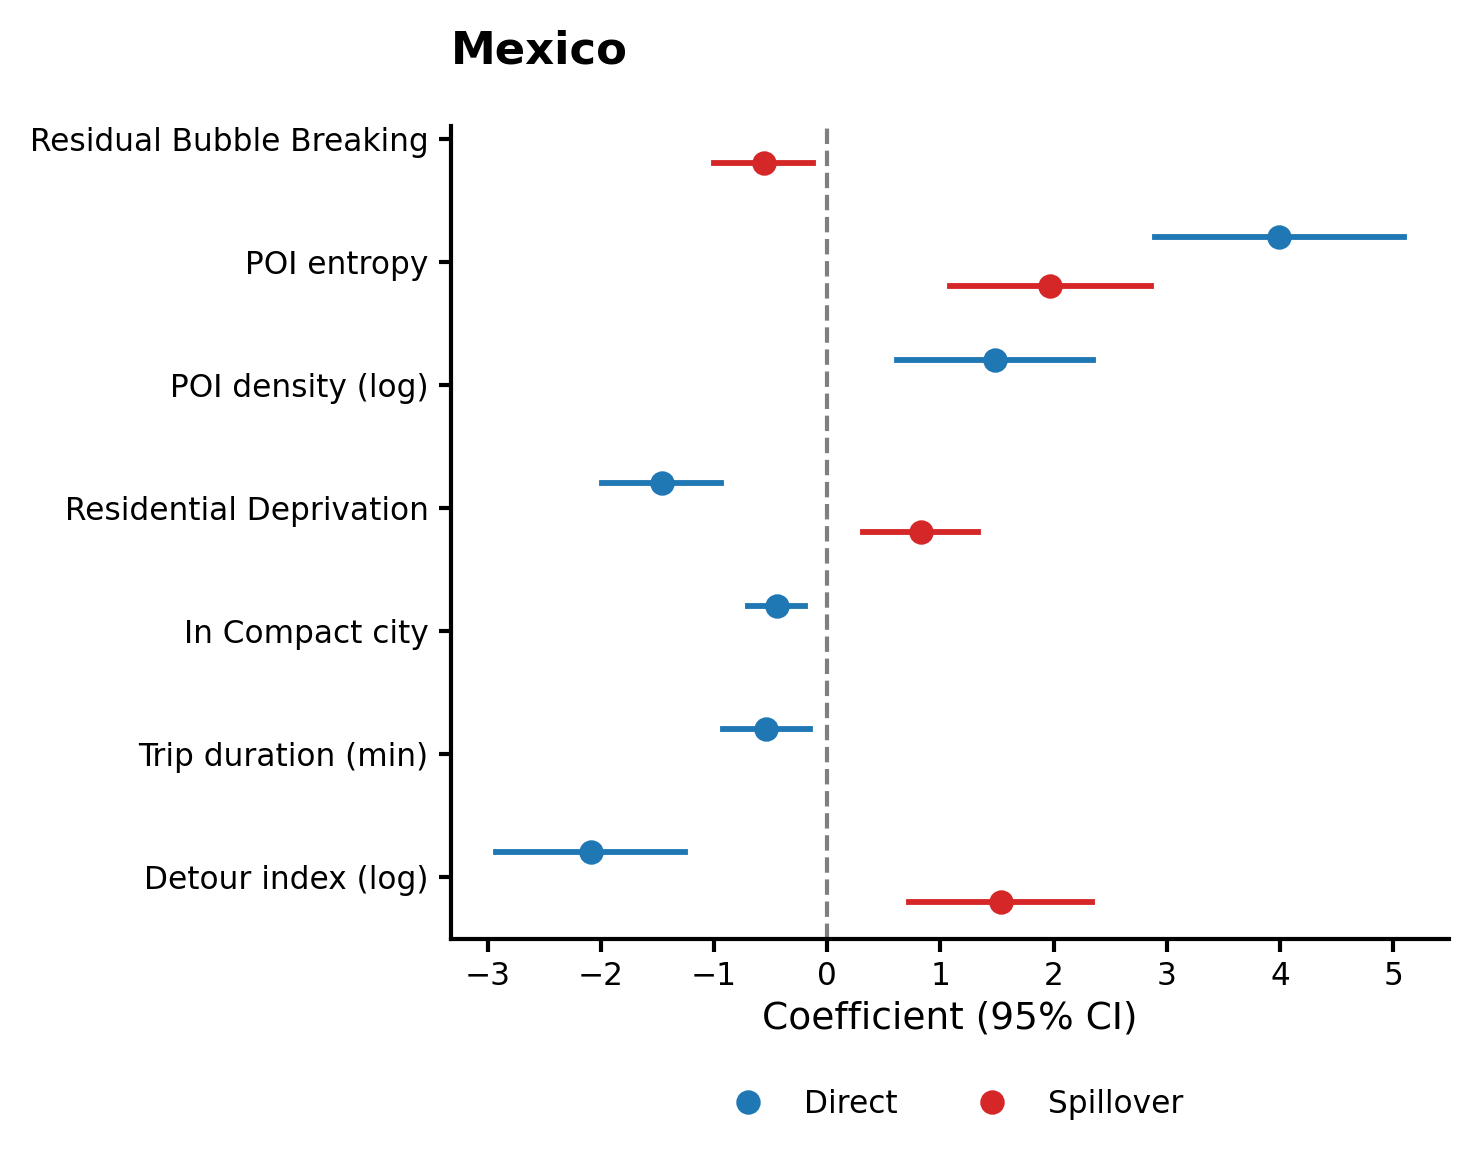

In [64]:
raw_effects = extract_logit_effects(logit_model,X_named,y)
raw_effects = raw_effects[raw_effects["p_value"] < 0.05]
plot_data = prepare_effects_df(raw_effects)
plot_sdm_effects(plot_data, country=country)

In [65]:
country = 'india'   # Alter this to get by-country results
column_to_fit = "Present after COVID?"
df2m = df_raw[df_raw['Country'] == country].dropna(subset = [column_to_fit]).copy()
# Zero-safe log transforms
df2m['log_detour'] = np.log(df2m['detour'] + 1e-6)
df2m['log_POI_density'] = np.log(df2m['POI density'] + 1e-6)

# Compactness dummy
df2m['compact_dummy'] = (df2m['Cluster_c'] == 'Compact').astype(int)

df2m["dummy_bubble"] = df2m["Bubble Breaking Gap PRE"] > df2m["Bubble Breaking Gap PRE"].median()
df2m['dummy_bubble'] = df2m['dummy_bubble'].astype(int)

# Add list of neighbors for each cell
df2m['neighbors'] = df2m['cell'].apply(
    lambda x: set(h3.k_ring(x, 1)) - {x}
)


cells_with_neighbors = set()
for _, row in df2m.iterrows():
    neighbors = set(h3.k_ring(row['cell'], 1)) - {row['cell']}
    neighbors_in_data = neighbors & set(df2m['cell'])
    if neighbors_in_data:
        cells_with_neighbors.add(row['cell'])

# Drop islands from the dataframe
df2m = df2m[df2m['cell'].isin(cells_with_neighbors)].copy()

# Now rebuild your adjacency dictionary and weights
id_to_idx = {cell: i for i, cell in enumerate(df2m['cell'])}
adj_dict = {id_to_idx[row['cell']]: 
            [id_to_idx[n] for n in row['neighbors'] if n in id_to_idx]
            for _, row in df2m.iterrows()}

W = libpysal.weights.W(adj_dict)
W.transform = 'r'  # row-standardize
y = df2m[column_to_fit].astype(int)

X_vars = ['Entropy', 'log_POI_density', 'Residential','dummy_bubble',
        'log_detour', 'wm_duration_min']    #'Entropy', 

X = df2m[X_vars].values
WX = W.sparse @ X   # W.sparse is the CSR matrix from\ libpysal

# build dataframe of WX with intuitive names
WX_df = pd.DataFrame(WX, columns=[f"W_{v}" for v in X_vars])

# combine into a single design matrix
X_all = pd.concat([df2m[X_vars].reset_index(drop=True),
                   WX_df.reset_index(drop=True)], axis=1)
X_all['compact_dummy'] = df2m['compact_dummy'].values

X_mat = X_all.values  # (n, 2k)


import statsmodels.api as sm

# Ensure X_all and df2m have same number of rows
print(len(X_all), len(df2m))

# Align by indexs
df_model = pd.concat(
    [df2m[[column_to_fit]].reset_index(drop=True),
     X_all.reset_index(drop=True)],
    axis=1
).dropna().reset_index(drop=True)

print(df_model.shape)   # Should be (n, 1 + k)

# Separate y and X
y = df_model[column_to_fit].astype(int)
X = df_model.drop(columns=[column_to_fit])

# Add constant
X_named = sm.add_constant(X)

logit_model = sm.Logit(y, X_named).fit(cov_type='HC3')
print(logit_model.summary())

1957 1957
(1957, 14)
Optimization terminated successfully.
         Current function value: 0.427132
         Iterations 7
                            Logit Regression Results                            
Dep. Variable:     Present after COVID?   No. Observations:                 1957
Model:                            Logit   Df Residuals:                     1943
Method:                             MLE   Df Model:                           13
Date:                  Mon, 09 Mar 2026   Pseudo R-squ.:                  0.3809
Time:                          12:36:21   Log-Likelihood:                -835.90
converged:                         True   LL-Null:                       -1350.2
Covariance Type:                    HC3   LLR p-value:                1.274e-211
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -8.3308      1.812     -4.598      0

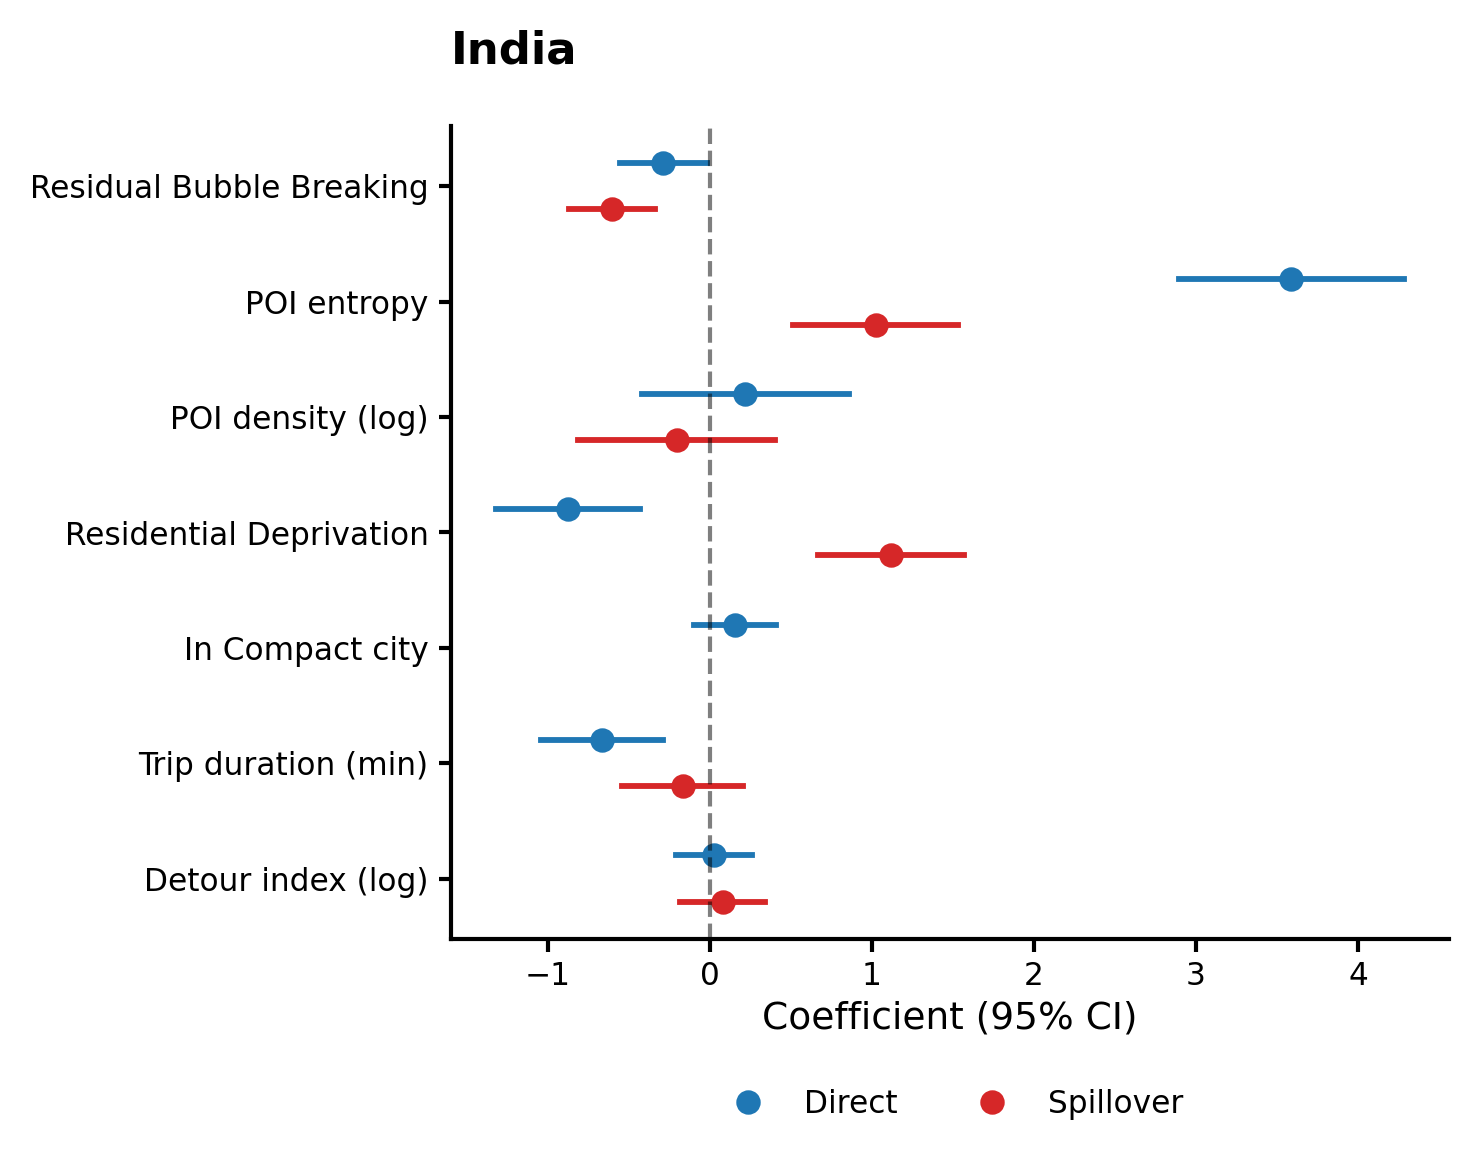

In [66]:
raw_effects = extract_logit_effects(logit_model,X_named,y)
plot_data = prepare_effects_df(raw_effects)
plot_sdm_effects(plot_data, country=country)